# 1.09 Data Clearning 

### Import libraries

In [6]:
import pandas as pd


data_frame = pd.read_csv('data/train.csv')

### create a copy of dataframe

In [7]:
df = data_frame.copy()

### show the shape of this dataframe

In [8]:
df.shape

(891, 12)

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# 1.09 Data Cleaning (Course Lab)

In this notebook we implement the key data-cleaning topics from the course:

- **1.1 Data Collection** (we load the dataset from `data/train.csv`)
- **1.2 Data Description & Understanding**
- **1.3 Handling Noise and Errors** (duplicates, inconsistent text/casing)
- **1.4 Handling Missing Values** (deletion, simple imputation, KNN, model-based)
- **1.5 Outlier Detection & Treatment** (IQR clipping, optional isolation forest)
- **1.6 Data Formatting** (types, parsing dates, memory optimization)
- **1.7 Data Quality Verification** (range checks, completeness checks, duplicates)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# pd.set_option('display.max_columns', 200)
# pd.set_option('display.width', 120)

df_raw = df.copy()
df_raw.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1.2 Data Description and Understanding
We start by understanding: shapes, dtypes, basic stats, and missingness patterns.

In [11]:
df_raw.shape, df_raw.columns.tolist()

((891, 12),
 ['PassengerId',
  'Survived',
  'Pclass',
  'Name',
  'Sex',
  'Age',
  'SibSp',
  'Parch',
  'Ticket',
  'Fare',
  'Cabin',
  'Embarked'])

In [12]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
df_raw.describe(include='all').T.head(30)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [14]:
def missing_report(frame):
    miss = frame.isna().sum()
    pct = (miss / len(frame)) * 100
    out = pd.DataFrame({'missing': miss, 'missing_%': pct})
    out = out.sort_values(['missing', 'missing_%'], ascending=False)
    return out[out['missing'] > 0]

missing_report(df_raw).head(30)

,missing,missing_%
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


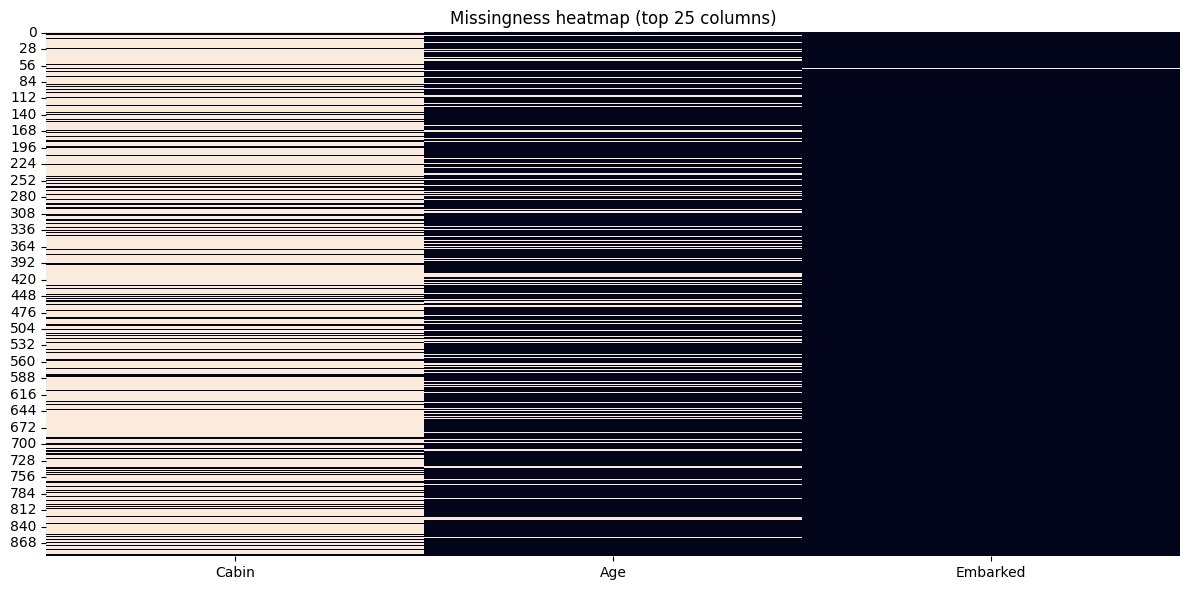

In [15]:
# Optional: visualize missingness (works best for moderate-width datasets)
mr = missing_report(df_raw)
if len(mr) > 0:
    top_cols = mr.index[:25].tolist()
    plt.figure(figsize=(12, 6))
    sns.heatmap(df_raw[top_cols].isna(), cbar=False)
    plt.title('Missingness heatmap (top 25 columns)')
    plt.tight_layout()
    plt.show()

## 1.3 Handling Noise and Errors
Typical noise/errors we check for:
- Duplicates
- Inconsistent text (spaces, casing)
- Impossible values (negative ages, etc.)

We’ll apply safe, generic cleaning that doesn’t assume a specific dataset schema.

In [16]:
df_work = df_raw.copy()

dup_count = int(df_work.duplicated().sum())
dup_count

0

In [17]:
if dup_count > 0:
    df_work = df_work.drop_duplicates().copy()

# Normalize object/text columns: strip spaces (safe, non-destructive)
obj_cols = df_work.select_dtypes(include=['object', 'string']).columns.tolist()
for c in obj_cols:
    df_work[c] = df_work[c].astype('string').str.strip()

df_work.shape

(891, 12)

## 1.4 Handling Missing Values
Missing values can bias models. We’ll implement multiple strategies:

1. **Deletion** (drop rows/columns)
2. **Simple imputation** (mean/median/mode/constant) + **missing indicators**
3. **KNN imputation (optional)** (numeric-only)

In [18]:
missing_report(df_work).head(40)

,missing,missing_%
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


### Strategy A — Deletion (rows/columns)

Use deletion when missingness is very small and random, or when a column is almost empty.
We demonstrate both **drop rows with any missing** and **drop columns below a threshold**.

In [19]:
df_drop_rows = df_work.dropna().copy()

col_threshold = int(0.7 * len(df_work))  # keep columns with >=70% non-missing
df_drop_cols = df_work.dropna(axis=1, thresh=col_threshold).copy()

pd.DataFrame({
    'original_rows': [len(df_work)],
    'drop_rows_any_missing': [len(df_drop_rows)],
    'original_cols': [df_work.shape[1]],
    'drop_cols_keep_70pct': [df_drop_cols.shape[1]],
})

,original_rows,drop_rows_any_missing,original_cols,drop_cols_keep_70pct
0,891,183,12,11


### Strategy B — Simple Imputation (+ Missing Indicators)

A strong baseline for many ML projects:
- Numeric: **median** (robust to outliers)
- Categorical/text: **mode** (most frequent) or a constant like `Unknown`
- Add `__was_missing` indicator columns so the model can learn missingness patterns

In [20]:
df_simple = df_work.copy()

# Add missing indicators (before imputation)
cols_with_missing = df_simple.columns[df_simple.isna().any()].tolist()
for c in cols_with_missing:
    df_simple[f'{c}__was_missing'] = df_simple[c].isna().astype('int8')

num_cols = df_simple.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df_simple.columns if c not in num_cols]

# Numeric: median
for c in num_cols:
    if df_simple[c].isna().any():
        df_simple[c] = df_simple[c].fillna(df_simple[c].median())

# Categorical: mode (fallback to 'Unknown')
for c in cat_cols:
    if df_simple[c].isna().any():
        mode = df_simple[c].mode(dropna=True)
        fill_value = mode.iloc[0] if len(mode) else 'Unknown'
        df_simple[c] = df_simple[c].fillna(fill_value)

missing_report(df_simple).head(20)

,missing,missing_%


### Strategy C — KNN Imputation (optional, numeric only)

KNNImputer fills missing numeric values based on nearest neighbors. This is a good demo of an “advanced” imputer, but still easy to use.

In [21]:
from sklearn.impute import KNNImputer

df_knn = df_work.copy()
num_cols = df_knn.select_dtypes(include=[np.number]).columns

if len(num_cols) > 0 and df_knn[num_cols].isna().any().any():
    imputer = KNNImputer(n_neighbors=5)
    df_knn[num_cols] = imputer.fit_transform(df_knn[num_cols])

missing_report(df_knn).head(20)

,missing,missing_%
Cabin,687,77.104377
Embarked,2,0.224467


### Quick Comparison of Missing-Value Strategies
We compare how much missingness remains after each approach (some methods impute numeric-only).

In [22]:
def compare_strategies(strategies):
    rows = []
    for name, frame in strategies.items():
        miss_cells = int(frame.isna().sum().sum())
        miss_cols = int((frame.isna().sum() > 0).sum())
        rows.append({
            'strategy': name,
            'rows': frame.shape[0],
            'cols': frame.shape[1],
            'missing_cells_total': miss_cells,
            'columns_with_missing': miss_cols,
        })
    return pd.DataFrame(rows).set_index('strategy').sort_values('missing_cells_total')

compare_strategies({
    'original': df_work,
    'drop_rows': df_drop_rows,
    'drop_cols': df_drop_cols,
    'simple+indicators': df_simple,
    'knn_numeric': df_knn,
})

,rows,cols,missing_cells_total,columns_with_missing
strategy,,,,
drop_rows,183,12,0,0
simple+indicators,891,15,0,0
drop_cols,891,11,179,2
knn_numeric,891,12,689,2
original,891,12,866,3


## 1.5 Outlier Detection and Treatment

Outliers can be measurement errors or rare events. A simple and common treatment is **IQR clipping** (winsorization).

In [23]:
def clip_iqr(series, k=1.5):
    if not np.issubdtype(series.dtype, np.number):
        return series
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return series
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return series.clip(lo, hi)

df_out = df_simple.copy()  # baseline: simple imputation + indicators
num_cols = df_out.select_dtypes(include=[np.number]).columns.tolist()

# If a label column exists, don't clip it:
label_like = [c for c in ['target', 'Target', 'y', 'label', 'Survived'] if c in df_out.columns]
num_cols_to_clip = [c for c in num_cols if c not in label_like]

for c in num_cols_to_clip:
    df_out[c] = clip_iqr(df_out[c])

df_out.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.0,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.0,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.0,2.0000,3.0000,3.0,3.0000
Age,891.0,29.039282,12.072074,2.5,22.0000,28.0000,35.0,54.5000
SibSp,891.0,0.426487,0.708246,0.0,0.0000,0.0000,1.0,2.5000
Parch,891.0,0.381594,0.806057,0.0,0.0000,0.0000,0.0,6.0000
Fare,891.0,24.046813,20.481625,0.0,7.9104,14.4542,31.0,65.6344
Age__was_missing,891.0,0.198653,0.399210,0.0,0.0000,0.0000,0.0,1.0000
Cabin__was_missing,891.0,0.771044,0.420397,0.0,1.0000,1.0000,1.0,1.0000
Embarked__was_missing,891.0,0.002245,0.047351,0.0,0.0000,0.0000,0.0,1.0000


## 1.6 Data Formatting

We make formats consistent and optionally optimize memory:
- Downcast numeric types
- Convert low-cardinality text columns to `category`
- Parse datetime columns if present

In [24]:
def optimize_dtypes(frame, max_unique_ratio=0.2):
    out = frame.copy()

    # Downcast numeric
    for c in out.select_dtypes(include=['int64', 'int32']).columns:
        out[c] = pd.to_numeric(out[c], downcast='integer')
    for c in out.select_dtypes(include=['float64', 'float32']).columns:
        out[c] = pd.to_numeric(out[c], downcast='float')

    # Convert low-cardinality object columns to category
    obj_cols = out.select_dtypes(include=['object', 'string']).columns
    n = len(out)
    for c in obj_cols:
        nunique = out[c].nunique(dropna=True)
        if n > 0 and (nunique / n) <= max_unique_ratio:
            out[c] = out[c].astype('category')

    # Attempt to parse obvious datetime columns
    for c in out.columns:
        if out[c].dtype == 'object' and any(k in c.lower() for k in ['date', 'time', 'timestamp']):
            parsed = pd.to_datetime(out[c], errors='coerce')
            if parsed.notna().mean() > 0.8:
                out[c] = parsed

    return out

mem_before = df_out.memory_usage(deep=True).sum() / (1024**2)
df_fmt = optimize_dtypes(df_out)
mem_after = df_fmt.memory_usage(deep=True).sum() / (1024**2)
mem_before, mem_after

(np.float64(0.3312101364135742), np.float64(0.1589651107788086))

## 1.7 Data Quality Verification

We build a small, reusable quality report:
- Completeness (missingness)
- Duplicates
- Basic numeric sanity checks

In [25]:
def data_quality_report(frame):
    report = {}
    report['rows'] = int(frame.shape[0])
    report['cols'] = int(frame.shape[1])
    report['duplicate_rows'] = int(frame.duplicated().sum())
    report['missing_cells_total'] = int(frame.isna().sum().sum())
    report['columns_with_missing'] = int((frame.isna().sum() > 0).sum())

    num = frame.select_dtypes(include=[np.number])
    if num.shape[1] > 0:
        report['numeric_negative_counts'] = int((num < 0).sum().sum())
        report['numeric_infinite_counts'] = int(np.isinf(num.to_numpy()).sum())
    else:
        report['numeric_negative_counts'] = 0
        report['numeric_infinite_counts'] = 0

    return report

pd.Series(data_quality_report(df_fmt))

rows                       891
cols                        15
duplicate_rows               0
missing_cells_total          0
columns_with_missing         0
numeric_negative_counts      0
numeric_infinite_counts      0
dtype: int64

## Export (Cleaned Dataset)

We export the cleaned dataset version we built (simple imputation + indicators + outlier clipping + formatting).

In [26]:
output_path = 'output/1.09_cleaned_train.csv'
df_fmt.to_csv(output_path, index=False)
output_path

'output/1.09_cleaned_train.csv'